In [1]:
# Core data science and plotting libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import math

from sklearn.model_selection import cross_val_score, RepeatedStratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from scipy.stats import randint

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)


In [2]:
df = pd.read_csv('../data/klasyfikacja/ortodoncja.csv',na_values=["?","NA",""])
df.head()

,9_SN/MP,9_Facial axis,9_Y-axis,9_Mn Base angle,9_Mn Ramus Angle,9_SNPog,9_SNB,9_SNA,9_SN/PP,9_ANB,9_AFH:PFH,9_PgNB,9_beta angle,12_SN/MP,12_Facial axis,12_Y-axis,12_Mn Base angle,12_Mn Ramus Angle,12_SNPog,12_SNB,12_SNA,12_SN/PP,12_ANB,12_AFH:PFH,12_PgNB,12_beta angle,growth direction
0,28.882655,87.411884,66.908260,0.415477,111.114850,75.585670,74.142998,80.118387,13.603083,-5.975389,1.414086,1.442672,22.508486,27.909820,86.576894,65.704419,1.685919,116.585770,77.233907,76.042877,80.645978,10.223444,-4.603101,1.416613,1.191030,22.220111,horizontal
1,35.410983,90.714247,67.379392,2.480978,123.868967,77.719090,75.980740,77.756093,6.041252,-1.775353,1.461818,1.738350,19.066329,33.743739,90.349278,67.648119,2.141797,120.371230,79.480178,77.289118,83.189766,2.538123,-5.900647,1.500294,2.191060,18.056378,horizontal
2,27.952347,90.827615,65.432107,2.277330,119.958531,78.909186,77.545863,81.804363,4.403767,-4.258501,1.343757,1.363323,21.822947,27.659934,89.636694,65.091970,3.492217,117.981833,80.125853,78.238824,81.127838,4.228677,-2.889014,1.341424,1.887029,22.169193,horizontal
3,25.138396,82.195544,59.619544,2.539409,118.323917,80.678309,78.714113,86.651762,1.864515,-7.937649,1.356391,1.964196,22.037847,24.174110,81.822303,59.646321,3.436016,118.071540,82.430061,80.259569,88.624746,-0.890545,-8.365177,1.355916,2.170492,21.251448,horizontal
4,33.761656,90.240915,65.960066,2.929263,126.728619,76.907767,76.334661,83.908674,14.651077,-7.574013,1.459953,0.573105,18.660648,33.334275,90.437338,65.913581,2.824466,128.441180,76.907972,76.362007,83.320338,13.187977,-6.958331,1.459762,0.545964,18.528448,normal


In [3]:
print("Shape of dataframe:", df.shape)

Shape of dataframe: (446, 27)


### Sprawdzenie braków danych

In [4]:
print("\nBraki danych w poszczególnych kolumnach:")
print(df.isnull().sum()[df.isnull().sum() > 0])


Braki danych w poszczególnych kolumnach:
Series([], dtype: int64)


### Usuwanie braków danych
Ze względu na małą ilość braków zdecydowano się usunąć wiersze z brakami

In [5]:
# Usunięcie wierszy, które zawierają co najmniej jedną brakującą wartość
print(f"Rozmiar zbioru przed usunięciem braków: {df.shape}")

df = df.dropna().reset_index(drop=True)

print(f"Rozmiar zbioru po usunięciu braków: {df.shape}")
print("Sprawdzenie braków po czyszczeniu:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Rozmiar zbioru przed usunięciem braków: (446, 27)
Rozmiar zbioru po usunięciu braków: (446, 27)
Sprawdzenie braków po czyszczeniu:
Series([], dtype: int64)


## Wizualizacja rozkładu cech

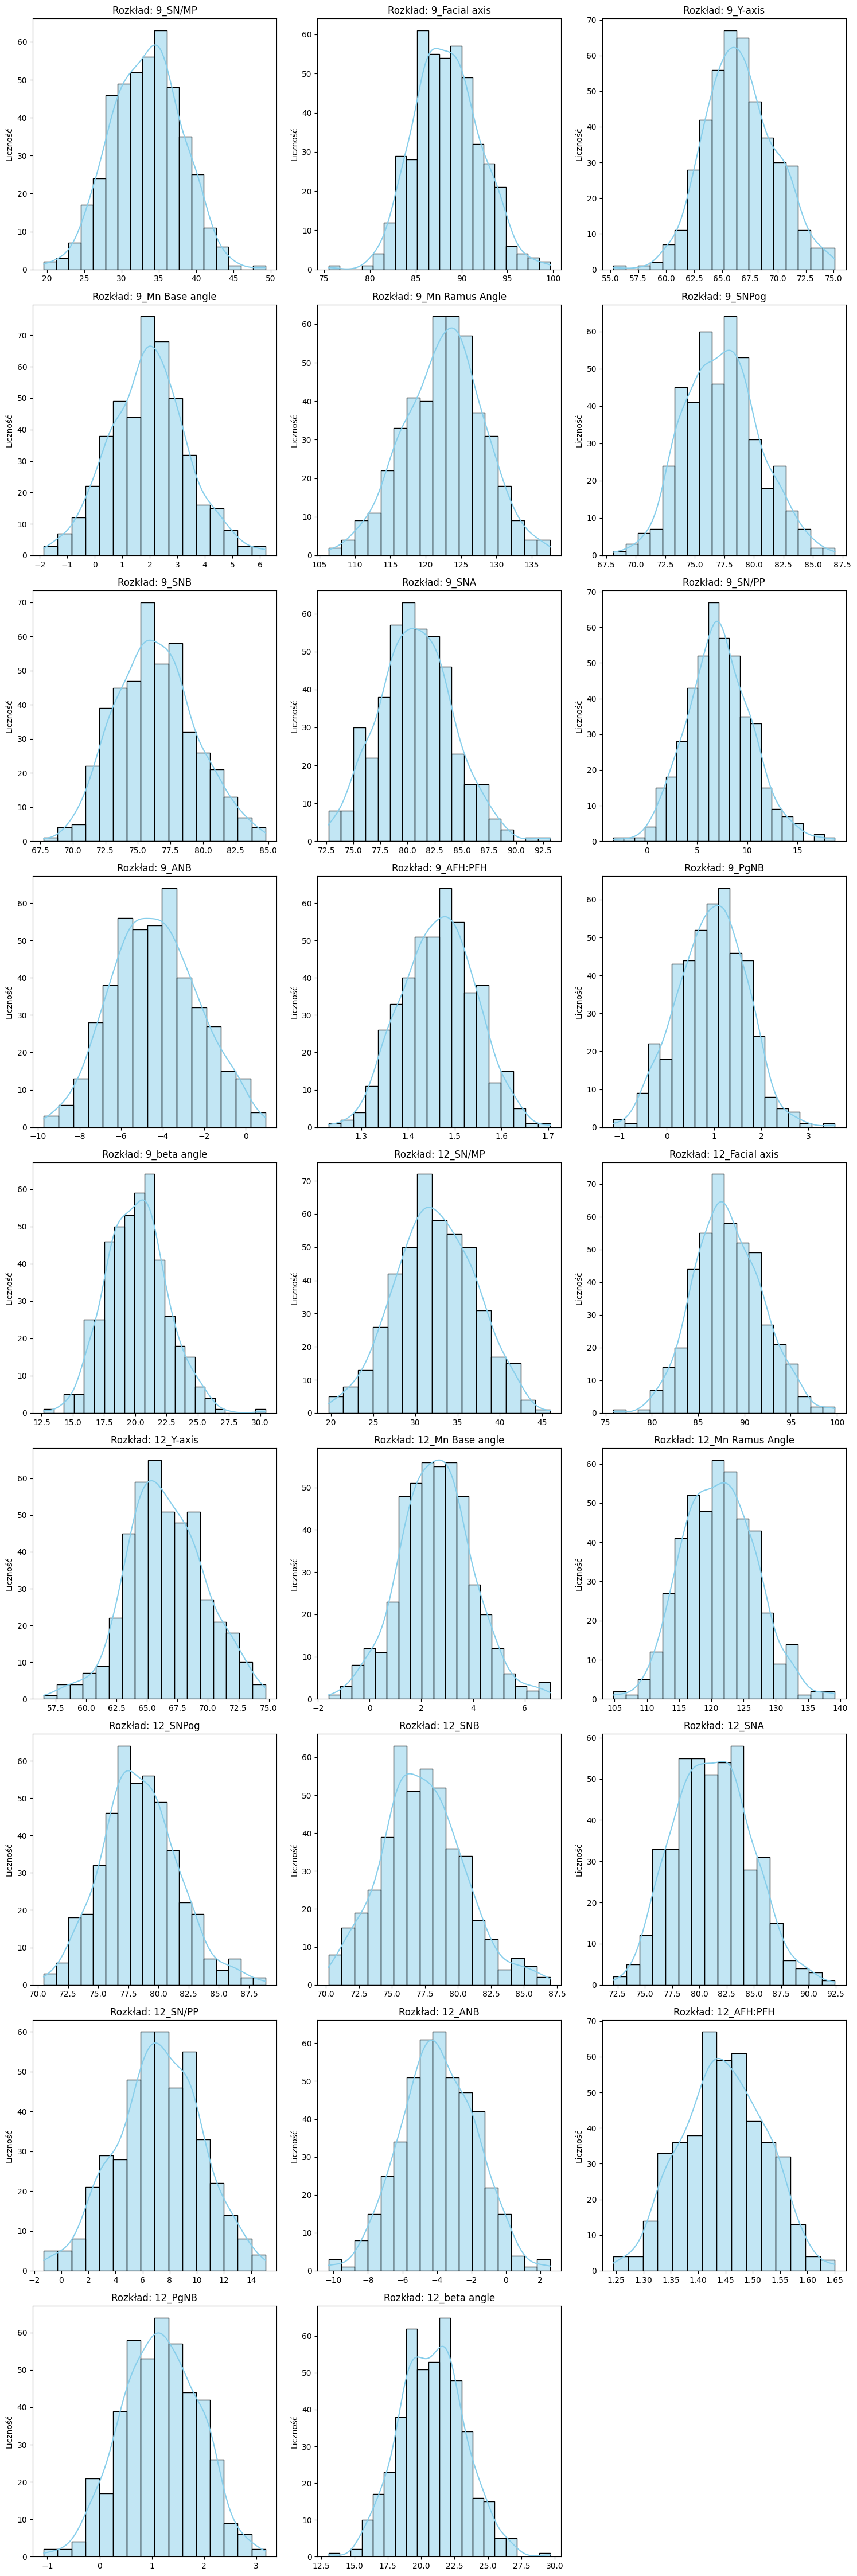

In [6]:
# Wybieramy tylko kolumny numeryczne (bez zmiennej celu jeśli jest kategoryczna)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Parametry siatki wykresów (np. 3 kolumny)
n_cols = 3
n_rows = math.ceil(len(numeric_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))

# Spłaszczamy osie do jednej listy (ułatwia to iterację)
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Rozkład: {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Liczność')

# Usuwamy puste osie, jeśli liczba cech nie jest wielokrotnością 3
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Wizualizacja rozkładu klas

Rozkład kierunku wzrostu:
growth direction
normal        246
horizontal    184
vertical       16
Name: count, dtype: int64


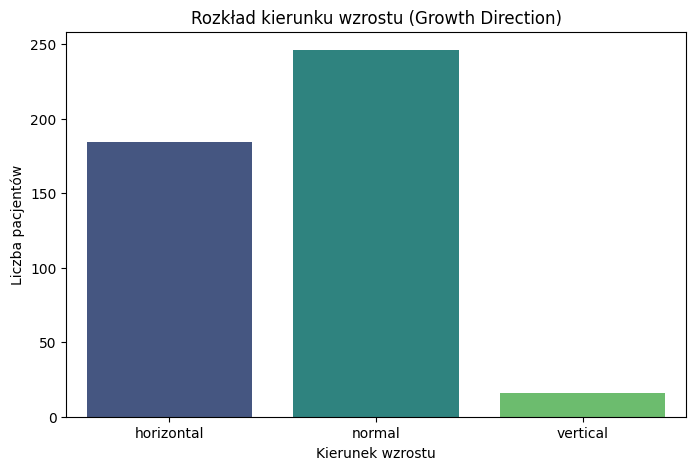

In [7]:
# Printujemy liczbe wystąpień każdej kategorii
target_col = 'growth direction'

print("Rozkład kierunku wzrostu:")
print(df[target_col].value_counts())

# Wykres
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df, 
    x=target_col, 
    hue=target_col,    # Rozwiązuje problem z paletą
    palette='viridis'
)

plt.title('Rozkład kierunku wzrostu (Growth Direction)')
plt.xlabel('Kierunek wzrostu')
plt.ylabel('Liczba pacjentów')
plt.show()

## Macierz korelacji

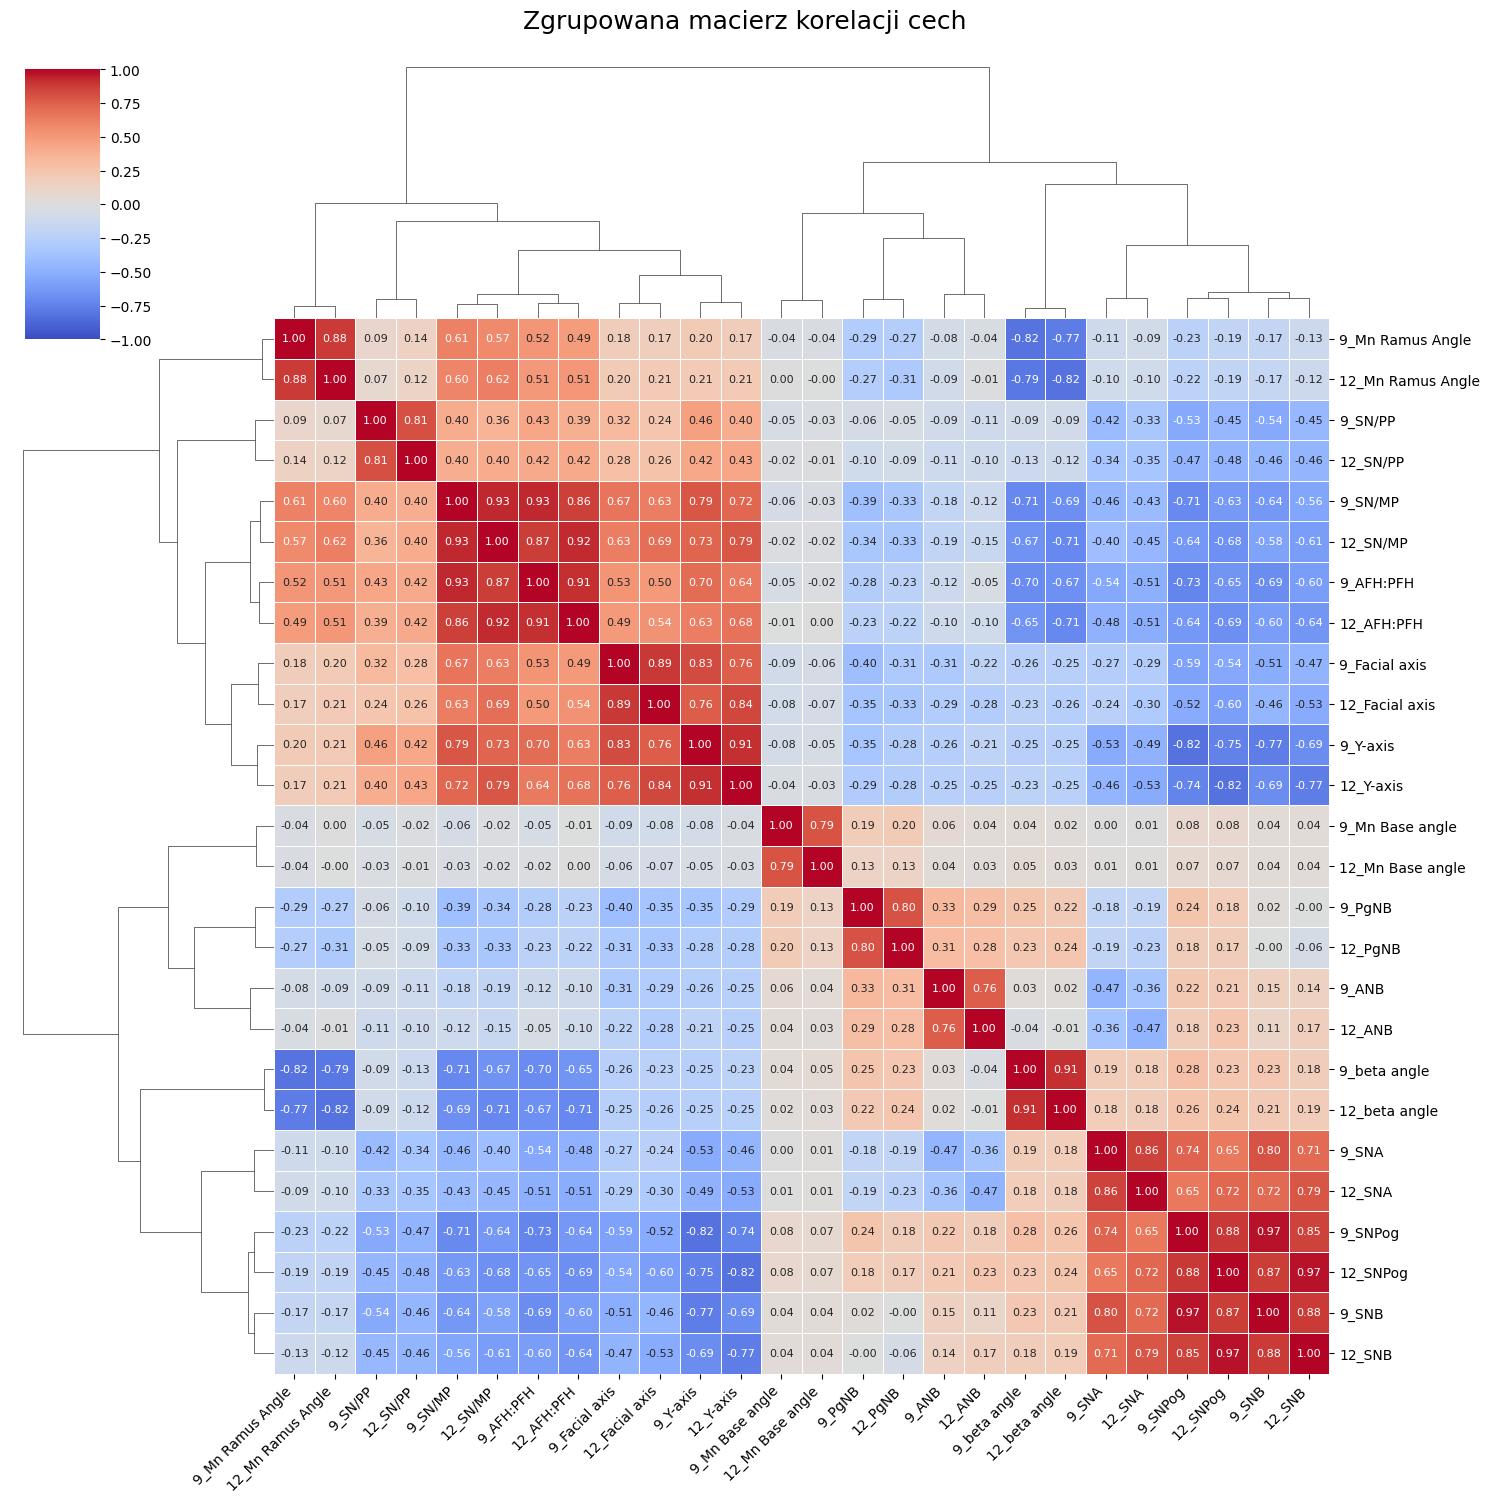

In [8]:
# Wybieramy tylko kolumny numeryczne (pomijamy kategoryczny 'growth direction')
numeric_features = df.select_dtypes(include=[np.number])

# Obliczamy korelację
corr = numeric_features.corr()

# Clustermap automatycznie grupuje podobne cechy
g = sns.clustermap(corr, 
                   cmap='coolwarm', 
                   vmin=-1, vmax=1, center=0,
                   annot=True, fmt=".2f", # Dodajemy liczby, ale małą czcionką
                   annot_kws={"size": 8},
                   linewidths=.5, 
                   figsize=(15, 15))

plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right')
g.fig.suptitle('Zgrupowana macierz korelacji cech', fontsize=18, y=1.02)
plt.show()

## Wizualizacja outlierów

Analiza wartości odstających (metoda IQR):
--------------------------------------------------
Cecha: 9_SN/MP         | Liczba outlierów:  3 | Granice: [20.56, 45.96]
Cecha: 9_Facial axis   | Liczba outlierów:  4 | Granice: [78.84, 97.88]
Cecha: 9_Y-axis        | Liczba outlierów:  3 | Granice: [58.15, 75.03]
Cecha: 9_Mn Base angle | Liczba outlierów:  3 | Granice: [-1.99, 5.77]
Cecha: 9_Mn Ramus Angle | Liczba outlierów:  3 | Granice: [107.86, 137.31]
Cecha: 9_SNPog         | Liczba outlierów:  3 | Granice: [68.84, 85.63]
Cecha: 9_SNB           | Liczba outlierów:  2 | Granice: [67.82, 84.52]
Cecha: 9_SNA           | Liczba outlierów:  2 | Granice: [71.87, 89.47]
Cecha: 9_SN/PP         | Liczba outlierów:  6 | Granice: [-1.03, 15.28]
Cecha: 9_ANB           | Brak outlierów
Cecha: 9_AFH:PFH       | Liczba outlierów:  2 | Granice: [1.26, 1.67]
Cecha: 9_PgNB          | Liczba outlierów:  4 | Granice: [-0.94, 2.86]
Cecha: 9_beta angle    | Liczba outlierów:  3 | Granice: [13.59, 26.36]
Cec

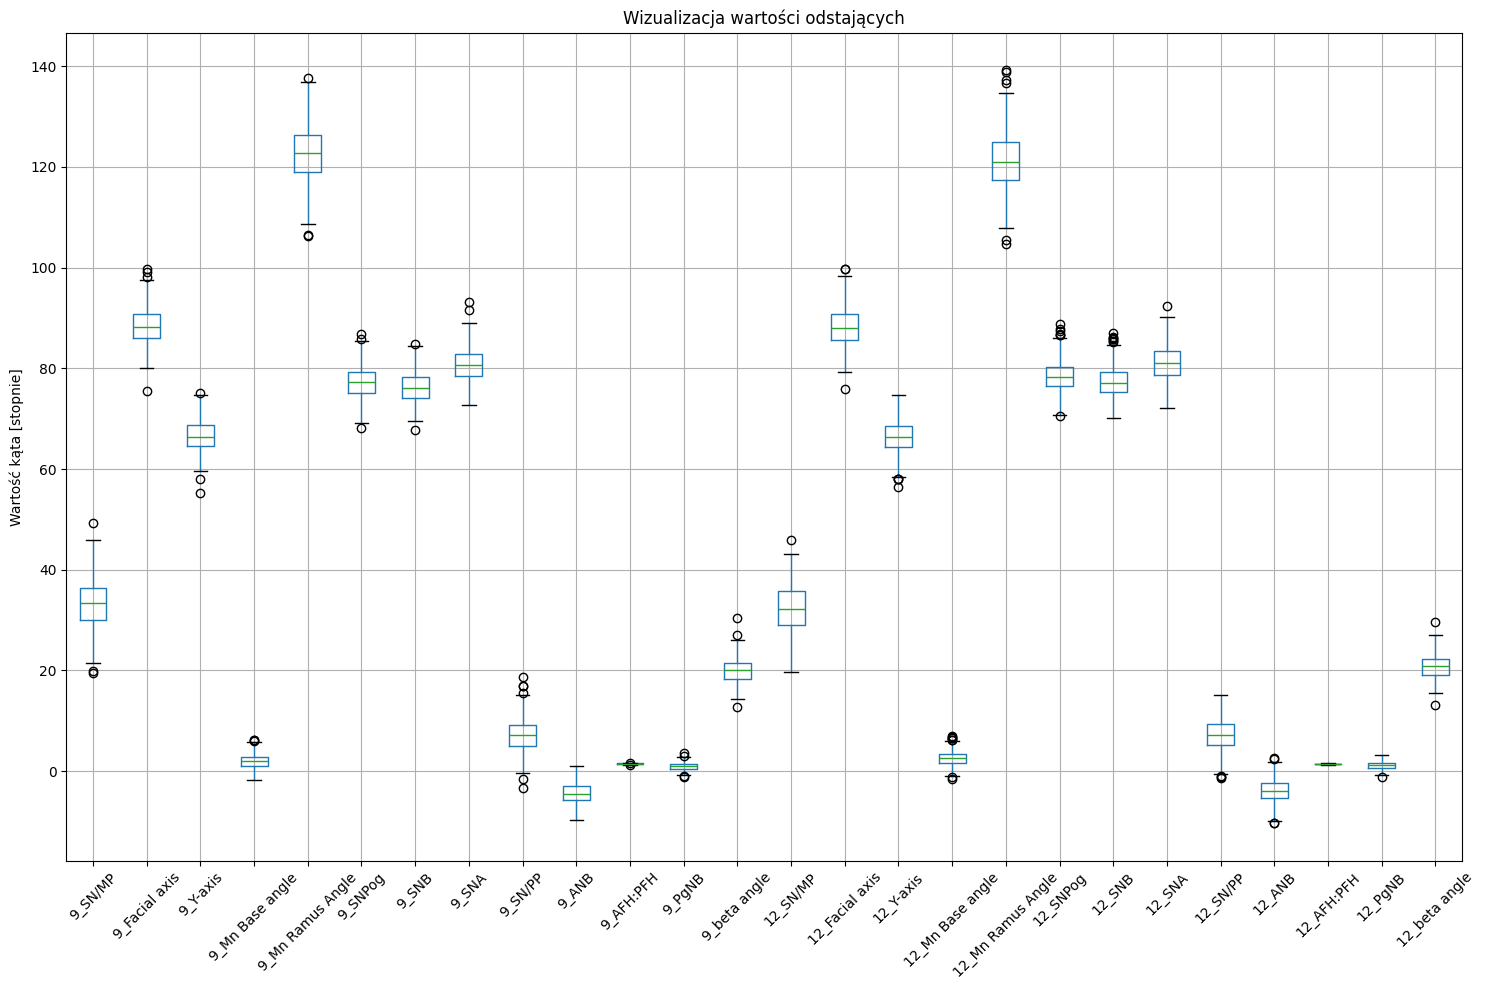

In [9]:
# Wybieramy tylko kolumny numeryczne (cechy 9_ i 12_)
feature_cols = [col for col in df.columns if col.startswith(('9_', '12_'))]

print("Analiza wartości odstających (metoda IQR):")
print("-" * 50)

outlier_summary = []

for col in feature_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Znajdujemy outliery
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    count = len(outliers)
    
    if count > 0:
        print(f"Cecha: {col:15} | Liczba outlierów: {count:2} | Granice: [{lower_bound:.2f}, {upper_bound:.2f}]")
        outlier_summary.append(count)
    else:
        print(f"Cecha: {col:15} | Brak outlierów")

print("-" * 50)
print(f"Łączna liczba wykrytych outlierów (suma wystąpień): {sum(outlier_summary)}")

# Tworzymy wykresy pudełkowe
plt.figure(figsize=(15, 10))
df[feature_cols].boxplot(rot=45)
plt.title("Wizualizacja wartości odstających")
plt.ylabel("Wartość kąta [stopnie]")
plt.tight_layout()
plt.show()

### Usuwanie outlinerów
Outliery prawdopodobnie są naturalne, więc zdecydowano się ich nie usuwać

In [10]:
"""def handle_outliers_iqr(df, columns):
    df_cleaned = df.copy()
    outlier_indices = []
    
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)

        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Znajdujemy indeksy outlierów
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)].index
        outlier_indices.extend(outliers)
        
    # Usuwamy duplikaty indeksów
    outlier_indices = list(set(outlier_indices))
    print(f"Liczba wykrytych wierszy z outlierami: {len(outlier_indices)}")
    
    # Decyzja: Usuwamy wiersze (najbezpieczniejsze przy małej liczbie outlierów)
    df_cleaned = df_cleaned.drop(outlier_indices).reset_index(drop=True)
    return df_cleaned

# Wykonujemy czyszczenie
df = handle_outliers_iqr(df, feature_cols)
print(f"Rozmiar zbioru po usunięciu outlierów: {df.shape}")"""

'def handle_outliers_iqr(df, columns):\n    df_cleaned = df.copy()\n    outlier_indices = []\n\n    for col in columns:\n        Q1 = df[col].quantile(0.25)\n        Q3 = df[col].quantile(0.75)\n\n        IQR = Q3 - Q1\n        lower_bound = Q1 - 1.5 * IQR\n        upper_bound = Q3 + 1.5 * IQR\n\n        # Znajdujemy indeksy outlierów\n        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)].index\n        outlier_indices.extend(outliers)\n\n    # Usuwamy duplikaty indeksów\n    outlier_indices = list(set(outlier_indices))\n    print(f"Liczba wykrytych wierszy z outlierami: {len(outlier_indices)}")\n\n    # Decyzja: Usuwamy wiersze (najbezpieczniejsze przy małej liczbie outlierów)\n    df_cleaned = df_cleaned.drop(outlier_indices).reset_index(drop=True)\n    return df_cleaned\n\n# Wykonujemy czyszczenie\ndf = handle_outliers_iqr(df, feature_cols)\nprint(f"Rozmiar zbioru po usunięciu outlierów: {df.shape}")'

## Kodowanie zmiennej docelowej

In [11]:
from sklearn.preprocessing import LabelEncoder

# Inicjalizacja LabelEncoder
le = LabelEncoder()

# Przekształcenie tekstowych wartości na numeryczne i dodanie nowej kolumny
df['growth direction_encoded'] = le.fit_transform(df['growth direction'])

# Wyświetlenie mapowania (aby wiedzieć, jaka liczba odpowiada danej klasie)
print("Mapowanie klas docelowych:", dict(zip(le.classes_, le.transform(le.classes_))))

# Usunięcie oryginalnej kolumny tekstowej, aby zostawić tylko numeryczne
df = df.drop('growth direction', axis=1)

Mapowanie klas docelowych: {'horizontal': np.int64(0), 'normal': np.int64(1), 'vertical': np.int64(2)}


# Podział na zbiór treningowy i testowy

In [12]:
from sklearn.model_selection import train_test_split

# 1. Wyodrębnienie cech (X) i zmiennej docelowej (y)
# Usuwamy z X kolumnę docelową 'growth direction_encoded', którą utworzyliśmy wcześniej
X = df.drop('growth direction_encoded', axis=1)
y = df['growth direction_encoded']

# 2. Podział danych
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Wymiary X_train: {X_train.shape}")
print(f"Wymiary X_test: {X_test.shape}")

Wymiary X_train: (356, 26)
Wymiary X_test: (90, 26)


## Standaryzacja cech numerycznych (skalowanie)

In [13]:
"""from sklearn.preprocessing import StandardScaler

# Inicjalizacja skalera
scaler = StandardScaler()

# Uczymy skaler (fit) na X_train i od razu transformujemy
X_train_scaled = scaler.fit_transform(X_train)

# Zbiór testowy TYLKO transformujemy (używając średniej i odchylenia z X_train)
X_test_scaled = scaler.transform(X_test)

# Konwersja z powrotem do DataFrame, aby zachować nazwy kolumn i ułatwić podgląd
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

print("Podgląd wystandaryzowanego zbioru treningowego:")
display(X_train_scaled_df.head())"""

'from sklearn.preprocessing import StandardScaler\n\n# Inicjalizacja skalera\nscaler = StandardScaler()\n\n# Uczymy skaler (fit) na X_train i od razu transformujemy\nX_train_scaled = scaler.fit_transform(X_train)\n\n# Zbiór testowy TYLKO transformujemy (używając średniej i odchylenia z X_train)\nX_test_scaled = scaler.transform(X_test)\n\n# Konwersja z powrotem do DataFrame, aby zachować nazwy kolumn i ułatwić podgląd\nX_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)\nX_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)\n\nprint("Podgląd wystandaryzowanego zbioru treningowego:")\ndisplay(X_train_scaled_df.head())'

# ==================================================
# Eksperymenty
# ==================================================

In [14]:
# Zdefiniowanie schematu kroswalidacji (wystarczy zrobić to raz)
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)

def evaluate_classification_model(model, X_train, y_train, X_test, y_test, model_name, cv=5):
    print(f"{'='*50}")
    print(f"EWALUACJA MODELU: {model_name}")
    print(f"{'='*50}")
    
    if isinstance(model, (GridSearchCV, RandomizedSearchCV)):
        # GridSearch wykonuje dopasowanie i kroswalidację wewnętrznie
        model.fit(X_train, y_train)
        
        # Pobieramy statystyki dla najlepszego zestawu parametrów
        best_index = model.best_index_
        mean_score = model.best_score_
        std_score = model.cv_results_['std_test_score'][best_index]
        
        print(f"Best CV Score (f1_macro) for {model_name}: {mean_score:.4f} (+/- {std_score:.4f})")
        print(f"Najlepsze parametry: {model.best_params_}\n")
        
        # Najlepszy estymator jest już dopasowany na całym X_train
        y_pred = model.predict(X_test)
    else:
        # Uruchamiamy kroswalidację na "świeżym" modelu
        cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1_macro', n_jobs=-1)
        mean_score = np.mean(cv_scores)
        std_score = np.std(cv_scores)
        
        print(f"Mean CV F1 Score for {model_name}: {mean_score:.4f} (+/- {std_score:.4f})\n")
        
        # Trenujemy model raz na pełnym zbiorze treningowym dla ostatecznej predykcji
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
    # Raport klasyfikacji
    print(f"Classification Report for {model_name}:")
    print(classification_report(y_test, y_pred))
    
    # Wykres macierzy pomyłek
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Macierz pomyłek - {model_name}')
    plt.xlabel('Przewidziana klasa')
    plt.ylabel('Rzeczywista klasa')
    plt.tight_layout()
    plt.show()
    
    return y_pred

# Drzewo decyzyjne

## Drzewo zwykłe

EWALUACJA MODELU: Drzewo Decyzyjne (Bazowe)
Mean CV F1 Score for Drzewo Decyzyjne (Bazowe): 0.5268 (+/- 0.0812)

Classification Report for Drzewo Decyzyjne (Bazowe):
              precision    recall  f1-score   support

           0       0.71      0.73      0.72        37
           1       0.76      0.74      0.75        50
           2       0.33      0.33      0.33         3

    accuracy                           0.72        90
   macro avg       0.60      0.60      0.60        90
weighted avg       0.72      0.72      0.72        90



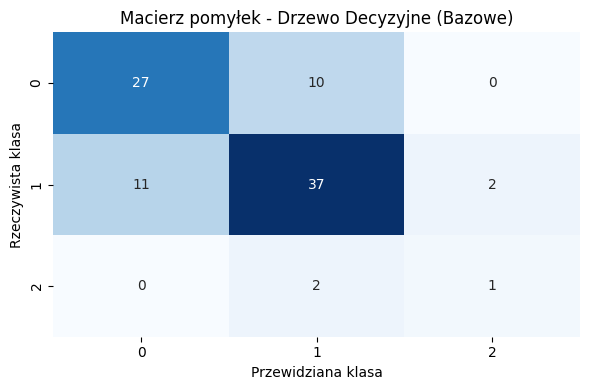

In [15]:
dt_baseline_pipeline = ImbPipeline(steps=[
    ('classifier', DecisionTreeClassifier(random_state=42))
])

y_pred_base = evaluate_classification_model(
    model=dt_baseline_pipeline,
    X_train=X_train,
    y_train=y_train, 
    X_test=X_test,
    y_test=y_test, 
    model_name="Drzewo Decyzyjne (Bazowe)",
    cv=cv
)

## Drzewo z SMOTE

EWALUACJA MODELU: Drzewo Decyzyjne (SMOTE)
Mean CV F1 Score for Drzewo Decyzyjne (SMOTE): 0.5908 (+/- 0.1233)

Classification Report for Drzewo Decyzyjne (SMOTE):
              precision    recall  f1-score   support

           0       0.70      0.76      0.73        37
           1       0.76      0.74      0.75        50
           2       0.00      0.00      0.00         3

    accuracy                           0.72        90
   macro avg       0.49      0.50      0.49        90
weighted avg       0.71      0.72      0.71        90



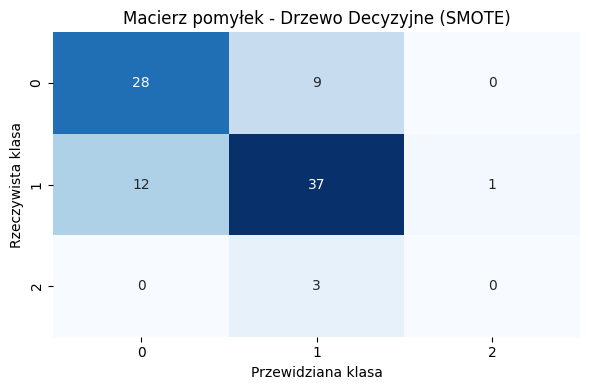

In [16]:
# Tworzymy Pipeline: najpierw SMOTE, potem klasyfikator
# Używamy ImbPipeline (z imbalanced-learn), a nie zwykłego ze sklearn!
dt_smote_pipeline = ImbPipeline(steps=[
    ('smote', SMOTE(random_state=42)),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# Ewaluacja modelu
y_pred_base_smote = evaluate_classification_model(
    model=dt_smote_pipeline, 
    X_train=X_train, 
    y_train=y_train, 
    X_test=X_test, 
    y_test=y_test, 
    model_name="Drzewo Decyzyjne (SMOTE)",
    cv=cv
)

## Drzewo ze SMOTE zoptymalizowane - grid search

EWALUACJA MODELU: Drzewo Decyzyjne (Grid Search + SMOTE)
Fitting 15 folds for each of 108 candidates, totalling 1620 fits
Best CV Score (f1_macro) for Drzewo Decyzyjne (Grid Search + SMOTE): 0.6233 (+/- 0.1004)
Najlepsze parametry: {'classifier__criterion': 'entropy', 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}

Classification Report for Drzewo Decyzyjne (Grid Search + SMOTE):
              precision    recall  f1-score   support

           0       0.87      0.70      0.78        37
           1       0.78      0.92      0.84        50
           2       1.00      0.33      0.50         3

    accuracy                           0.81        90
   macro avg       0.88      0.65      0.71        90
weighted avg       0.82      0.81      0.80        90



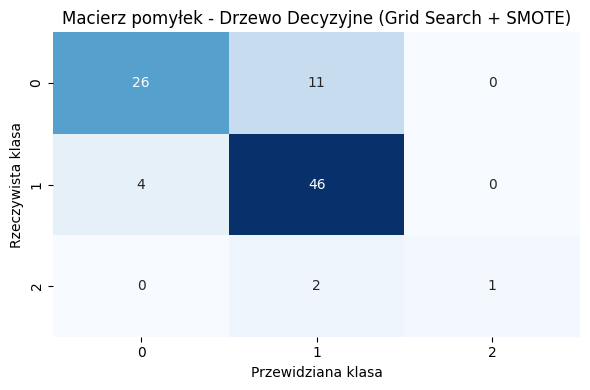

In [17]:
# Definicja potoku: SMOTE + Klasyfikator
dt_smote_pipeline = ImbPipeline(steps=[
    ('smote', SMOTE(random_state=42)),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# Definicja siatki hiperparametrów
# WAŻNE: Dodajemy prefiks 'classifier__' do każdej nazwy parametru
param_grid_dt_smote = {
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__max_depth': [None, 3, 5, 7, 10, 15],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}

# Inicjalizacja Grid Search na przygotowanym potoku
grid_search_dt_smote = GridSearchCV(
    estimator=dt_smote_pipeline,
    param_grid=param_grid_dt_smote,
    cv=cv,               
    scoring='f1_macro', 
    n_jobs=-1,
    verbose=1            
)

# Ewaluacja modelu
y_pred_opt_smote = evaluate_classification_model(
    model=grid_search_dt_smote, 
    X_train=X_train, 
    y_train=y_train, 
    X_test=X_test, 
    y_test=y_test, 
    model_name="Drzewo Decyzyjne (Grid Search + SMOTE)"
)

## Drzewo ze SMOTE, grid search oraz inżynierią cech

### Inżynieria cech

In [18]:
# --- KROK 1: Tworzenie cech Delta (Dynamika wzrostu) ---
# TWORZYMY KOPIĘ, aby nie nadpisać globalnego df!
df_dt = df.copy() 

cols_9 = [col for col in df_dt.columns if col.startswith('9_')]
for col_9 in cols_9:
    col_12 = col_9.replace('9_', '12_')
    if col_12 in df_dt.columns:
        # Obliczamy przyrost/spadek parametrów w czasie na lokalnej kopii
        df_dt[col_9.replace('9_', 'delta_')] = df_dt[col_12] - df_dt[col_9]

# --- KROK 2: Selekcja - usuwamy surowe dane z wieku 9 lat ---
# Dane te są już zawarte w 'delta' i '12_', więc stanowią szum
df_engineered = df_dt.drop(columns=cols_9)

# --- KROK 3: Aktualizacja podziału danych (ROBIMY TO PRZED KORELACJĄ!) ---
X_dt = df_engineered.drop('growth direction_encoded', axis=1)
y_dt = df_engineered['growth direction_encoded']
X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(
    X_dt, y_dt, test_size=0.2, random_state=42, stratify=y_dt
)

# --- KROK 4: Automatyczne usuwanie wysokiej korelacji (> 0.9) ---
# Uwaga: Macierz korelacji liczymy TYLKO na zbiorze treningowym (X_train_dt)
corr_matrix = X_train_dt.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

# Usuwamy wysoce skorelowane cechy z OBU zbiorów
X_train_dt = X_train_dt.drop(columns=to_drop)
X_test_dt = X_test_dt.drop(columns=to_drop)

print(f"Liczba cech (zmiennych objaśniających) po inżynierii i selekcji: {X_train_dt.shape[1]}")

Liczba cech (zmiennych objaśniających) po inżynierii i selekcji: 23


### Drzewo

EWALUACJA MODELU: Drzewo Decyzyjne (Engineering + SMOTE + GridSearch)
Fitting 15 folds for each of 72 candidates, totalling 1080 fits
Best CV Score (f1_macro) for Drzewo Decyzyjne (Engineering + SMOTE + GridSearch): 0.6049 (+/- 0.0757)
Najlepsze parametry: {'classifier__criterion': 'gini', 'classifier__max_depth': 3, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 10}

Classification Report for Drzewo Decyzyjne (Engineering + SMOTE + GridSearch):
              precision    recall  f1-score   support

           0       0.90      0.70      0.79        37
           1       0.85      0.88      0.86        50
           2       0.33      1.00      0.50         3

    accuracy                           0.81        90
   macro avg       0.69      0.86      0.72        90
weighted avg       0.85      0.81      0.82        90



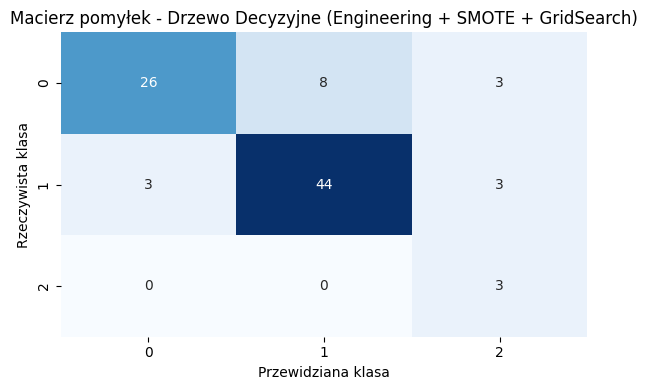

In [19]:
# Definicja potoku: SMOTE + Klasyfikator
dt_smote_pipeline = ImbPipeline(steps=[
    ('smote', SMOTE(random_state=42)),
    ('classifier', DecisionTreeClassifier(random_state=42, class_weight='balanced'))
])

# Definicja siatki hiperparametrów - zawężona, aby uniknąć overfittingu
param_grid_dt_smote = {
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__max_depth': [3, 5, 7, 10],            # Krótsze drzewa lepiej uogólniają
    'classifier__min_samples_split': [5, 10, 15],      # Więcej próbek do podziału = mniej szumu
    'classifier__min_samples_leaf': [2, 4, 6]
}

# Inicjalizacja Grid Search
grid_search_dt_smote = GridSearchCV(
    estimator=dt_smote_pipeline,
    param_grid=param_grid_dt_smote,
    cv=cv,               
    scoring='f1_macro', 
    n_jobs=-1,
    verbose=1            
)

# Ewaluacja modelu
y_pred_opt_smote = evaluate_classification_model(
    model=grid_search_dt_smote, 
    X_train=X_train_dt,  # <-- Zmieniono na zbiór po inżynierii cech
    y_train=y_train_dt,  # <-- Zmieniono na zbiór po inżynierii cech
    X_test=X_test_dt,    # <-- Zmieniono na zbiór po inżynierii cech
    y_test=y_test_dt,    # <-- Zmieniono na zbiór po inżynierii cech
    model_name="Drzewo Decyzyjne (Engineering + SMOTE + GridSearch)"
)

# Random Forest

EWALUACJA MODELU: Random Forest (Bazowy)
Mean CV F1 Score for Random Forest (Bazowy): 0.5602 (+/- 0.0869)

Classification Report for Random Forest (Bazowy):
              precision    recall  f1-score   support

           0       0.88      0.81      0.85        37
           1       0.82      0.92      0.87        50
           2       0.00      0.00      0.00         3

    accuracy                           0.84        90
   macro avg       0.57      0.58      0.57        90
weighted avg       0.82      0.84      0.83        90



c:\Users\maciek\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\maciek\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\maciek\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

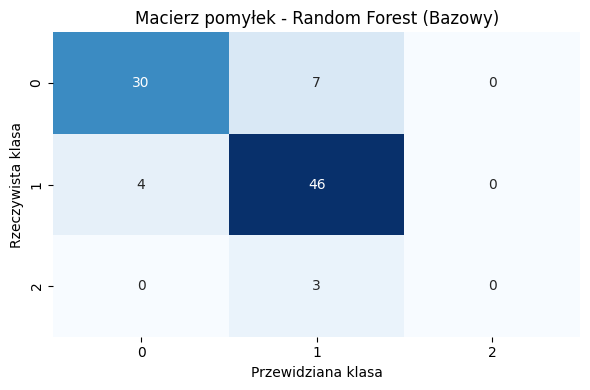

In [20]:
rf_baseline_pipeline = ImbPipeline(steps=[
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

y_pred_rf = evaluate_classification_model(
    model=rf_baseline_pipeline, 
    X_train=X_train, 
    y_train=y_train, 
    X_test=X_test, 
    y_test=y_test, 
    model_name="Random Forest (Bazowy)",
    cv=cv
)

## Random Forest ze SMOTE

EWALUACJA MODELU: Random Forest (SMOTE)
Mean CV F1 Score for Random Forest (SMOTE): 0.6594 (+/- 0.1142)

Classification Report for Random Forest (SMOTE):
              precision    recall  f1-score   support

           0       0.86      0.84      0.85        37
           1       0.87      0.90      0.88        50
           2       1.00      0.67      0.80         3

    accuracy                           0.87        90
   macro avg       0.91      0.80      0.84        90
weighted avg       0.87      0.87      0.87        90



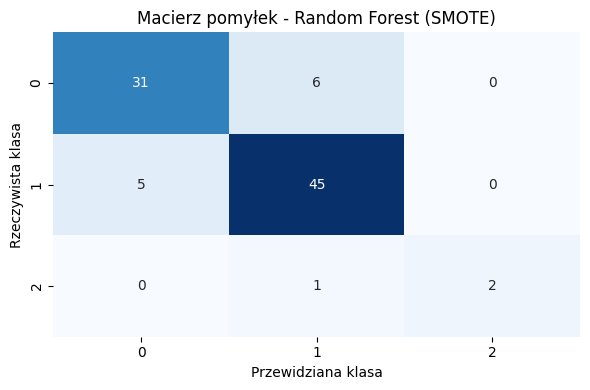

In [21]:
# Definicja potoku: najpierw SMOTE, potem model Random Forest
rf_smote_pipeline = ImbPipeline(steps=[
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Ewaluacja modelu
y_pred_rf_smote = evaluate_classification_model(
    model=rf_smote_pipeline, 
    X_train=X_train, 
    y_train=y_train, 
    X_test=X_test, 
    y_test=y_test, 
    model_name="Random Forest (SMOTE)",
    cv=cv
)

## Random Forest ze SMOTE oraz grid search

EWALUACJA MODELU: Random Forest (Grid Search + SMOTE)
Fitting 15 folds for each of 216 candidates, totalling 3240 fits
Best CV Score (f1_macro) for Random Forest (Grid Search + SMOTE): 0.6774 (+/- 0.0999)
Najlepsze parametry: {'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 100}

Classification Report for Random Forest (Grid Search + SMOTE):
              precision    recall  f1-score   support

           0       0.86      0.84      0.85        37
           1       0.87      0.90      0.88        50
           2       1.00      0.67      0.80         3

    accuracy                           0.87        90
   macro avg       0.91      0.80      0.84        90
weighted avg       0.87      0.87      0.87        90



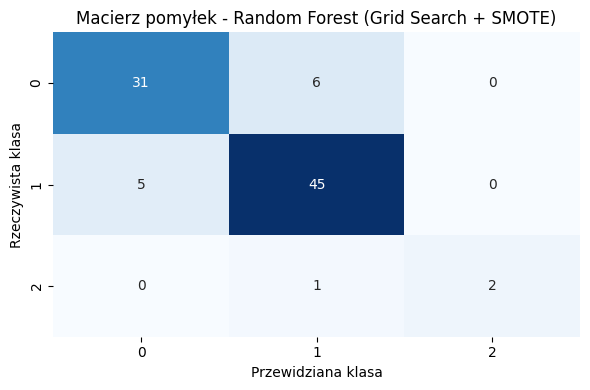

In [22]:
# Definicja potoku: Skaler -> SMOTE -> Random Forest
rf_smote_pipeline = ImbPipeline(steps=[
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Definicja siatki hiperparametrów
param_grid_rf = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [None, 10, 20, 30],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__max_features': ['sqrt', 'log2']
}

# Inicjalizacja Grid Search
grid_search_rf = GridSearchCV(
    estimator=rf_smote_pipeline,
    param_grid=param_grid_rf,
    cv=cv,              
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

# Ewaluacja zoptymalizowanego modelu
y_pred_rf_opt = evaluate_classification_model(
    model=grid_search_rf,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    model_name="Random Forest (Grid Search + SMOTE)"
)

## Random Forest ze SMOTE oraz randomized grid search

EWALUACJA MODELU: Random Forest (Random Search + SMOTE)
Fitting 15 folds for each of 50 candidates, totalling 750 fits
Best CV Score (f1_macro) for Random Forest (Random Search + SMOTE): 0.6752 (+/- 0.0954)
Najlepsze parametry: {'classifier__max_depth': 40, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 3, 'classifier__min_samples_split': 3, 'classifier__n_estimators': 487}

Classification Report for Random Forest (Random Search + SMOTE):
              precision    recall  f1-score   support

           0       0.83      0.81      0.82        37
           1       0.85      0.88      0.86        50
           2       1.00      0.67      0.80         3

    accuracy                           0.84        90
   macro avg       0.89      0.79      0.83        90
weighted avg       0.85      0.84      0.84        90



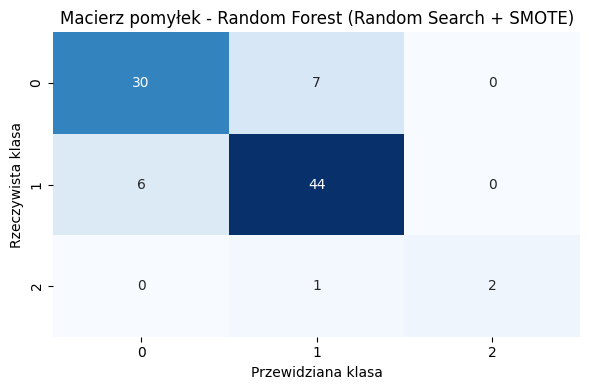

In [23]:
# Definicja potoku
rf_smote_pipeline = ImbPipeline(steps=[
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Definicja rozkładów parametrów
# W RandomizedSearch możemy używać zakresów (distributions), co jest bardziej efektywne
param_dist_rf = {
    'classifier__n_estimators': randint(100, 500),          # Losowa liczba drzew z zakresu
    'classifier__max_depth': [None, 10, 20, 30, 40, 50],
    'classifier__min_samples_split': randint(2, 11),        # Losowa liczba z zakresu 2-10
    'classifier__min_samples_leaf': randint(1, 5),          # Losowa liczba z zakresu 1-4
    'classifier__max_features': ['sqrt', 'log2', None]
}

# Inicjalizacja Randomized Search
random_search_rf = RandomizedSearchCV(
    estimator=rf_smote_pipeline,
    param_distributions=param_dist_rf,
    n_iter=50,             # Liczba wylosowanych kombinacji do sprawdzenia
    cv=cv, 
    scoring='f1_macro', 
    random_state=42,       # Zapewnia powtarzalność losowania
    n_jobs=-1,
    verbose=1
)

# Ewaluacja zoptymalizowanego modelu
y_pred_rf_opt = evaluate_classification_model(
    model=random_search_rf, 
    X_train=X_train, 
    y_train=y_train, 
    X_test=X_test, 
    y_test=y_test, 
    model_name="Random Forest (Random Search + SMOTE)"
)

## Random forest z SMOTE, grid search oraz inżynierią cech

### Inżynieria cech

In [24]:
# Przygotowanie kopii danych do inżynierii
df_rf = df.copy()

# --- KROK 1: Różnice (Delty) ---
# Obliczamy dynamikę zmian między 12 a 9 rokiem życia
cols_9 = [col for col in df_rf.columns if col.startswith('9_')]
for col_9 in cols_9:
    col_12 = col_9.replace('9_', '12_')
    if col_12 in df_rf.columns:
        df_rf[col_9.replace('9_', 'delta_')] = df_rf[col_12] - df_rf[col_9]

# --- KROK 2: Wskaźniki (Ratios) ---
# Wybieramy pary cech o bardzo wysokiej korelacji (>0.85) z Twojej macierzy
# Przykładowe pary logiczne w ortodoncji (dostosuj nazwy jeśli są inne w Twoim csv):
ratio_pairs = [
    ('12_SNA', '12_SNB'), # Proporcja szczęki do żuchwy
    ('12_NL', '12_NSL'),  # Relacje kątowe podstaw czaszki
]

for col_a, col_b in ratio_pairs:
    if col_a in df_rf.columns and col_b in df_rf.columns:
        # Unikamy dzielenia przez zero (jeśli występuje)
        df_rf[f'ratio_{col_a}_{col_b}'] = df_rf[col_a] / (df_rf[col_b] + 1e-6)

# --- KROK 3: Selekcja - usuwamy surowe dane 9_ (szum) ---
df_rf_engineered = df_rf.drop(columns=cols_9)

# --- KROK 4: Podział danych (PRZED analizą korelacji) ---
X_rf = df_rf_engineered.drop('growth direction_encoded', axis=1)
y_rf = df_rf_engineered['growth direction_encoded']

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf, y_rf, test_size=0.2, random_state=42, stratify=y_rf
)

# --- KROK 5: Usuwanie duplikatów korelacyjnych (>0.95) TYLKO na X_train_rf ---
corr_matrix = X_train_rf.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]

X_train_rf = X_train_rf.drop(columns=to_drop)
X_test_rf = X_test_rf.drop(columns=to_drop)

print(f"Liczba cech po rozszerzonej inżynierii dla RF: {X_train_rf.shape[1]}")

Liczba cech po rozszerzonej inżynierii dla RF: 24


### Random forest

EWALUACJA MODELU: Random Forest (Deltas + Ratios + SMOTE)
Fitting 15 folds for each of 36 candidates, totalling 540 fits
Best CV Score (f1_macro) for Random Forest (Deltas + Ratios + SMOTE): 0.6387 (+/- 0.1001)
Najlepsze parametry: {'classifier__max_depth': 5, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 4, 'classifier__n_estimators': 500}

Classification Report for Random Forest (Deltas + Ratios + SMOTE):
              precision    recall  f1-score   support

           0       0.81      0.81      0.81        37
           1       0.86      0.84      0.85        50
           2       0.75      1.00      0.86         3

    accuracy                           0.83        90
   macro avg       0.81      0.88      0.84        90
weighted avg       0.83      0.83      0.83        90



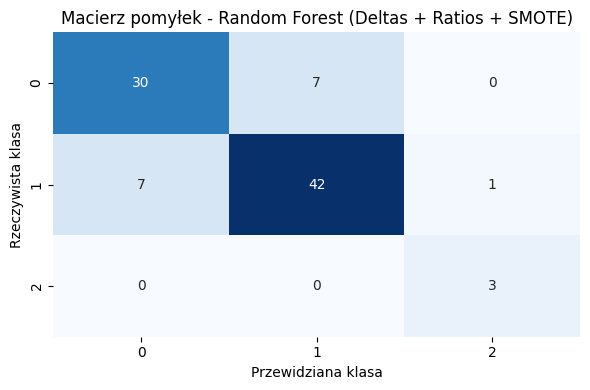

In [25]:
# Definicja potoku (bez skalera, RF go nie potrzebuje)
rf_advanced_pipeline = ImbPipeline(steps=[
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

# Siatka parametrów uwzględniająca siłę modelu [cite: 47]
param_grid_rf = {
    'classifier__n_estimators': [100, 300, 500],
    'classifier__max_depth': [5, 10, 15],
    'classifier__min_samples_leaf': [2, 4],
    'classifier__max_features': ['sqrt', 'log2'] # Ważne przy dużej liczbie delt i ratios
}

grid_rf = GridSearchCV(
    estimator=rf_advanced_pipeline,
    param_grid=param_grid_rf,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

# Ewaluacja
y_pred_rf = evaluate_classification_model(
    model=grid_rf,
    X_train=X_train_rf,
    y_train=y_train_rf,
    X_test=X_test_rf,
    y_test=y_test_rf,
    model_name="Random Forest (Deltas + Ratios + SMOTE)"
)

# K-Nearest Neighbors

## Zwykły K-Nearest Neighbours

EWALUACJA MODELU: KNN (Bazowy)
Mean CV F1 Score for KNN (Bazowy): 0.5003 (+/- 0.0673)

Classification Report for KNN (Bazowy):
              precision    recall  f1-score   support

           0       0.80      0.76      0.78        37
           1       0.78      0.86      0.82        50
           2       0.00      0.00      0.00         3

    accuracy                           0.79        90
   macro avg       0.53      0.54      0.53        90
weighted avg       0.76      0.79      0.77        90



c:\Users\maciek\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\maciek\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\maciek\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

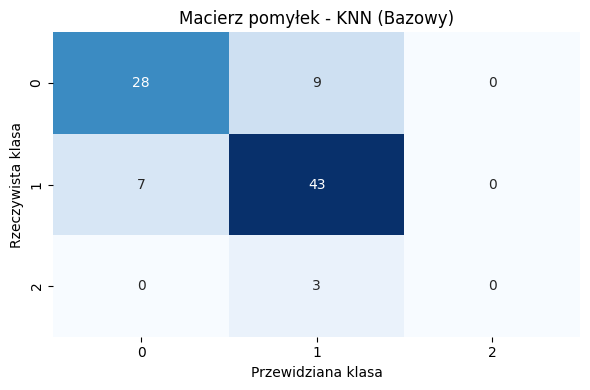

In [26]:
knn_baseline_pipeline = ImbPipeline(steps=[
    ('scaler', StandardScaler()),
    ('classifier', KNeighborsClassifier(n_neighbors=5))
])

y_pred_knn = evaluate_classification_model(
    model=knn_baseline_pipeline, 
    X_train=X_train, 
    y_train=y_train, 
    X_test=X_test, 
    y_test=y_test, 
    model_name="KNN (Bazowy)",
    cv=cv
)

## K-Nearest Neighbors z SMOTE

EWALUACJA MODELU: K-Nearest Neighbors (Bazowy + SMOTE)
Mean CV F1 Score for K-Nearest Neighbors (Bazowy + SMOTE): 0.5537 (+/- 0.0861)

Classification Report for K-Nearest Neighbors (Bazowy + SMOTE):
              precision    recall  f1-score   support

           0       0.72      0.84      0.78        37
           1       0.88      0.72      0.79        50
           2       0.50      1.00      0.67         3

    accuracy                           0.78        90
   macro avg       0.70      0.85      0.74        90
weighted avg       0.80      0.78      0.78        90



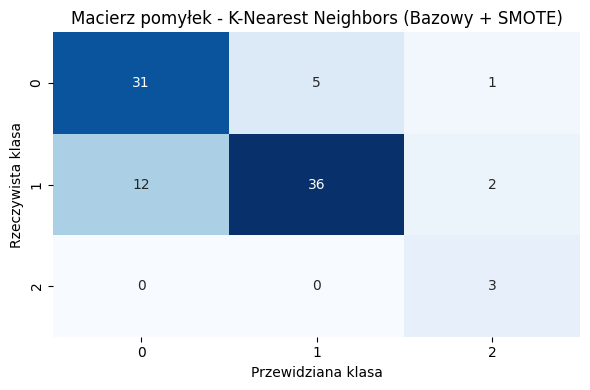

In [27]:
# Definicja potoku: SMOTE + KNN
knn_smote_pipeline = ImbPipeline(steps=[
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('classifier', KNeighborsClassifier(n_neighbors=5))
])

# Ewaluacja modelu
y_pred_knn_smote = evaluate_classification_model(
    model=knn_smote_pipeline, 
    X_train=X_train, 
    y_train=y_train, 
    X_test=X_test, 
    y_test=y_test, 
    model_name="K-Nearest Neighbors (Bazowy + SMOTE)",
    cv=cv
)

## K-Nearest Neighbors z SMOTE oraz grid search

EWALUACJA MODELU: KNN (Grid Search + SMOTE)
Fitting 15 folds for each of 42 candidates, totalling 630 fits
Best CV Score (f1_macro) for KNN (Grid Search + SMOTE): 0.5773 (+/- 0.0699)
Najlepsze parametry: {'classifier__metric': 'minkowski', 'classifier__n_neighbors': 9, 'classifier__p': 2, 'classifier__weights': 'uniform'}

Classification Report for KNN (Grid Search + SMOTE):
              precision    recall  f1-score   support

           0       0.71      0.86      0.78        37
           1       0.89      0.68      0.77        50
           2       0.43      1.00      0.60         3

    accuracy                           0.77        90
   macro avg       0.68      0.85      0.72        90
weighted avg       0.80      0.77      0.77        90



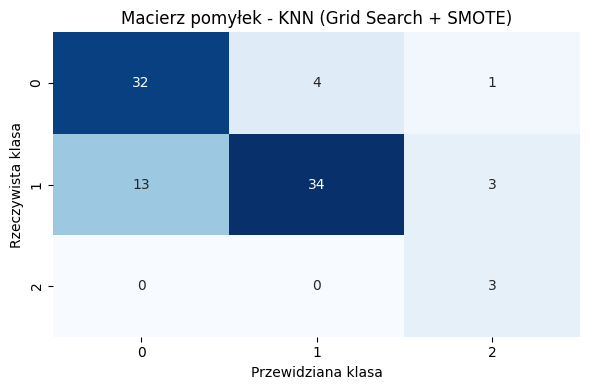

In [28]:
# Definicja potoku: SMOTE + KNN
knn_smote_pipeline = ImbPipeline(steps=[
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('classifier', KNeighborsClassifier())
])

# Definicja siatki hiperparametrów
param_grid_knn_smote = {
    'classifier__n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'classifier__weights': ['uniform', 'distance'],
    'classifier__metric': ['minkowski'],
    'classifier__p': [1, 2, 3] # 1=Manhattan, 2=Euclidean, 3=Często ciekawe wyniki
}

# Inicjalizacja Grid Search na potoku
grid_search_knn_smote = GridSearchCV(
    estimator=knn_smote_pipeline,
    param_grid=param_grid_knn_smote,
    cv=cv,               
    scoring='f1_macro', 
    n_jobs=-1,
    verbose=1
)

# Ewaluacja modelu
y_pred_knn_opt_smote = evaluate_classification_model(
    model=grid_search_knn_smote, 
    X_train=X_train, 
    y_train=y_train, 
    X_test=X_test, 
    y_test=y_test, 
    model_name="KNN (Grid Search + SMOTE)"
)

## K-Nearest Neighbors z SMOTE, grid search oraz inżynierią cech

EWALUACJA MODELU: KNN (Deltas + PCA + SMOTE + GridSearch)
Fitting 15 folds for each of 20 candidates, totalling 300 fits
Best CV Score (f1_macro) for KNN (Deltas + PCA + SMOTE + GridSearch): 0.5387 (+/- 0.0614)
Najlepsze parametry: {'classifier__n_neighbors': 3, 'classifier__p': 2, 'classifier__weights': 'uniform'}

Classification Report for KNN (Deltas + PCA + SMOTE + GridSearch):
              precision    recall  f1-score   support

           0       0.49      0.62      0.55        37
           1       0.66      0.46      0.54        50
           2       0.38      1.00      0.55         3

    accuracy                           0.54        90
   macro avg       0.51      0.69      0.54        90
weighted avg       0.58      0.54      0.54        90



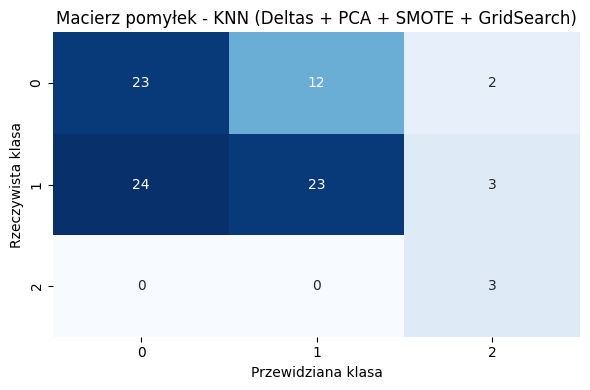

In [29]:
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif

# 1. PRZYGOTOWANIE DANYCH (Wykorzystujemy logikę delt z poprzedniego eksperymentu)
# Tworzymy kopię, aby nie psuć głównego df
df_knn = df.copy()

# Tworzenie delt - dynamika jest kluczowa dla odległości w KNN
cols_9 = [col for col in df_knn.columns if col.startswith('9_')]
for col_9 in cols_9:
    col_12 = col_9.replace('9_', '12_')
    if col_12 in df_knn.columns:
        df_knn[col_9.replace('9_', 'delta_')] = df_knn[col_12] - df_knn[col_9]

# Usuwamy surowe 9_, zostawiamy 12_ i delty
df_knn = df_knn.drop(columns=cols_9)

# 2. AKTUALIZACJA PODZIAŁU
X_k = df_knn.drop('growth direction_encoded', axis=1)
y_k = df_knn['growth direction_encoded']

X_train_k, X_test_k, y_train_k, y_test_k = train_test_split(
    X_k, y_k, test_size=0.2, random_state=42, stratify=y_k
)

# 3. DEFINICJA ZAAWANSOWANEGO POTOKU
# PCA pomaga KNN "zrozumieć" strukturę danych bez szumu korelacyjnego
knn_advanced_pipeline = ImbPipeline(steps=[
    ('scaler', StandardScaler()),       # Obowiązkowe dla KNN
    ('pca', PCA(n_components=0.95)),    # Zachowujemy 95% informacji, redukując wymiary
    ('smote', SMOTE(random_state=42)),  # Balansowanie klas
    ('classifier', KNeighborsClassifier())
])

# 4. SIATKA PARAMETRÓW
# Sprawdzamy metrykę Manhattan (p=1), która często lepiej działa w przestrzeniach wielowymiarowych
param_grid_knn = {
    'classifier__n_neighbors': [3, 5, 7, 9, 11],
    'classifier__weights': ['uniform', 'distance'],
    'classifier__p': [1, 2] 
}

# 5. URUCHOMIENIE I EWALUACJA
grid_knn_adv = GridSearchCV(
    estimator=knn_advanced_pipeline,
    param_grid=param_grid_knn,
    cv=cv, 
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

y_pred_knn_adv = evaluate_classification_model(
    model=grid_knn_adv,
    X_train=X_train_k,
    y_train=y_train_k,
    X_test=X_test_k,
    y_test=y_test_k,
    model_name="KNN (Deltas + PCA + SMOTE + GridSearch)"
)